In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
#importing all necessary libraries

In [ ]:
from google.colab import files
uploaded=files.upload()
df=pd.read_csv('bermuda_shorts.csv')
df.head(100)
#importing mydata csv file
#showing full table

Saving bermuda_shorts.csv to bermuda_shorts.csv


,Unnamed: 0,seqn,bmdstats,bmxwt,bmiwt,bmxrecum,bmirecum,bmxhead,bmihead,bmxht,...,bmxarmc,bmiarmc,bmxwaist,bmiwaist,bmxsad1,bmxsad2,bmxsad3,bmxsad4,bmdavsad,bmdsadcm
0,1,62161,1,69.2,NaN,NaN,NaN,NaN,NaN,172.3,...,32.5,NaN,81.0,NaN,17.7,17.9,NaN,NaN,17.8,NaN
1,2,62162,1,12.7,NaN,95.7,NaN,NaN,NaN,94.7,...,16.6,NaN,45.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,62163,1,49.4,NaN,NaN,NaN,NaN,NaN,168.9,...,22.0,NaN,64.6,NaN,15.6,15.5,NaN,NaN,15.6,NaN
3,4,62164,1,67.2,NaN,NaN,NaN,NaN,NaN,170.1,...,29.3,NaN,80.1,NaN,18.3,18.5,NaN,NaN,18.4,NaN
4,5,62165,1,69.1,NaN,NaN,NaN,NaN,NaN,159.4,...,29.7,NaN,86.7,NaN,21.0,20.8,NaN,NaN,20.9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,62262,1,10.2,NaN,73.5,NaN,NaN,NaN,NaN,...,15.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,97,62263,3,17.5,3.0,98.2,NaN,NaN,NaN,97.4,...,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
97,98,62264,1,86.5,NaN,NaN,NaN,NaN,NaN,166.7,...,31.4,NaN,112.0,NaN,26.8,27.3,NaN,NaN,27.1,NaN
98,99,62265,1,99.3,NaN,NaN,NaN,NaN,NaN,177.9,...,35.7,NaN,110.0,NaN,26.5,26.5,NaN,NaN,26.5,NaN


In [ ]:
df=df.dropna(subset=['bmxleg','bmxwaist']) #drops all NA values in the columns

Text(0, 0.5, 'waist circumference length (cm)')

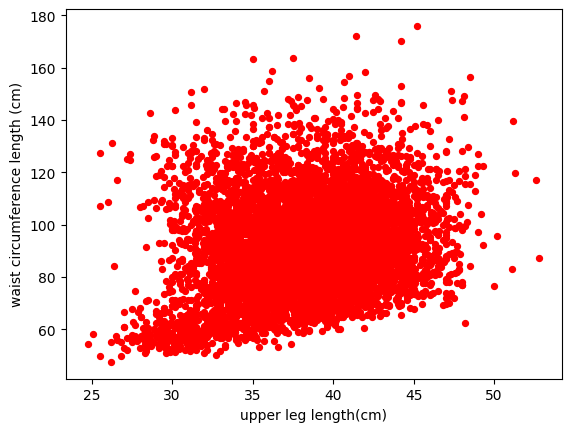

In [ ]:
plt.scatter(df['bmxleg'],df['bmxwaist'],c='red', s=18)
#making a scatter plot with red dots and dot size 18
#inserting data from x and y columns
plt.xlabel ('upper leg length(cm)') #making a x and y label for the scatter plot
plt.ylabel ('waist circumference length (cm)')

In [ ]:
k=2
#k is 2 because there is only 2 columns
#its how many clusters you want
X=np.array(list(zip(df['bmxleg'],df['bmxwaist'])))#creates a matrix with all points
model=KMeans(n_clusters=k) #creating a model variable
kmeans=model.fit(X) #the fit function trains the model and its perameters
labels=model.predict(X) #predict function assigns all a label to all points
centroids=model.cluster_centers_ #indentifies the centroids
print(labels)#prints the labels and centroids of the clusters
print(centroids)

[0 0 0 ... 0 1 0]
[[ 37.62840782  77.43022346]
 [ 38.81413076 107.45890328]]


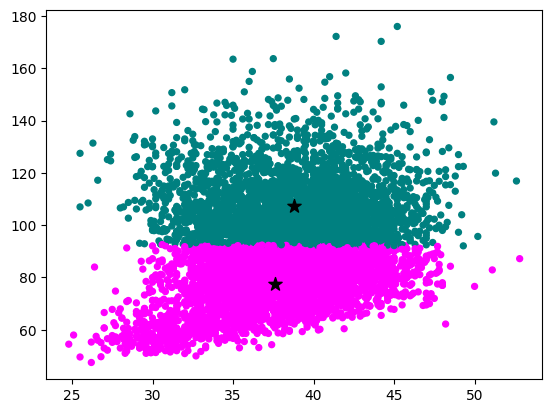

In [ ]:
c=['magenta', 'teal', 'yellow', 'red'] #Plots the points and centroids of each cluster
colors=[c[i] for i in labels] #maps the labels in colors
plt.scatter(df['bmxleg'],df['bmxwaist'], c=colors, s=18)
plt.scatter(centroids[:,0], centroids[:,1], marker='*', s=100, c='black')

In [ ]:
cluster=model.predict([[37,111]])[0] #Making predictions off the cluster model we just trained

print(c[cluster])

teal


In [ ]:
from sklearn.metrics import silhouette_score

model=KMeans(n_clusters=2)
model.fit(X)
label=model.predict(X)

print(f'silhouette Score(n=2):  {silhouette_score(X,label)}')

model=KMeans(n_clusters=3)
model.fit(X)
label=model.predict(X)

print(f'silhouette Score(n=2):  {silhouette_score(X,label)}')
#Gives you the silhouette coefficient score
#changing the n_clusters to 3 to see the score difference

silhouette Score(n=2):  0.5168032452901105
silhouette Score(n=2):  0.4714957755674397
